# 23. Hallucination and Failure Modes in AI Causal Analysis

Hallucination in causal analysis includes fake citations, invented variables, and methodological failures. The more dangerous hallucinations are often methodological: treating targeted assignment as random, inventing an identifying assumption, calling a post-treatment variable a confounder, or turning a fragile diagnostic into a confident rollout recommendation.

This notebook catalogs common AI failure modes in causal workflows and builds deterministic detectors for them. The goal is not to eliminate all AI mistakes. The goal is to make failure visible before it affects a decision.

## Mathematical Core

A hallucination is an unsupported claim, so it can be scored as a binary event. For response $r_i$ and evidence set $E_i$,

$$
H_i = \mathbf{1}\{r_i \; \text{contains a claim unsupported by}\; E_i\}.
$$

The empirical hallucination rate is

$$
\hat h = \frac{1}{n}\sum_{i=1}^{n} H_i.
$$

In causal analysis, the most dangerous failures often concern assumptions. A model may invent randomization, overlap, timing, or measurement details. The evaluation should therefore score both factual support and causal-design validity.

For claim-level review, precision is often more informative than fluency:

$$
\widehat{\mathrm{precision}} = \frac{N_{\mathrm{supported}}}{N_{\mathrm{claims}}}.
$$

For causal analysis, the denominator should include factual claims, design claims, and assumption claims. A response that cites facts correctly can still fail if it invents identification assumptions.


## Learning Goals

By the end of this notebook, you should be able to:

- Distinguish factual hallucination from causal-method hallucination.
- Detect hallucinated columns, citations, diagnostics, and assumptions.
- Identify bad-control and timing errors in generated adjustment sets and code.
- Redline causal overclaims in generated reports.
- Build an auditable failure taxonomy for AI causal workflows.
- Stress-test local models on failure-mode cases.
- Explain why brittle model behavior is itself a risk signal.

## Live Model Note

Failure-mode notebooks are brittle by design. We are intentionally prompting models near their weak spots: ambiguous assignment processes, tempting bad controls, incomplete diagnostics, and plausible but unsupported claims.

If a model fails on one rerun and passes on another, the workflow is unstable and the problem should remain on the risk register. In causal work, rerun instability should be logged, scored, and treated as evidence that human review and deterministic checks are required.

## 1. Setup

We will use structured artifacts so the detectors can inspect the same fields each time: design, adjustment set, diagnostics, citations, generated code, and final report language.

In [1]:
# Section focus: 1. Setup.
# The code below keeps the calculation explicit so each intermediate step can be inspected.

import json
import re
import sys
import warnings
from copy import deepcopy
from pathlib import Path
from typing import Any, Literal

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display
from pydantic import BaseModel, Field

warnings.filterwarnings('ignore', category=FutureWarning)
sns.set_theme(style='whitegrid', context='notebook')

PROJECT_ROOT = Path.cwd()
for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / 'notebooks' / '_shared' / 'local_llm.py').exists():
        PROJECT_ROOT = candidate
        break

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f'Project root: {PROJECT_ROOT}')

from notebooks._shared.display import smart_display


Project root: repository root


In [2]:
RUN_LIVE_LOCAL_LLM = True
RUN_FULL_MODEL_COMPARISON = True
RUN_SCHEMA_REPAIR_RETRY = True

MODEL_ID = 'Qwen/Qwen2.5-14B-Instruct'
MAX_NEW_TOKENS = 2100
COMPACT_MAX_NEW_TOKENS = 900
TEMPERATURE = 0.0
SEED = 223
MODEL_COMPARISON_CASE_LIMIT = 3

try:
    import torch
    print(f'CUDA available to this kernel: {torch.cuda.is_available()}')
except Exception as exc:
    print(f'Torch availability check failed: {exc}')

CUDA available to this kernel: True


In [3]:
try:
    from notebooks._shared.local_llm import DEFAULT_MODELS_TO_COMPARE
except Exception:
    DEFAULT_MODELS_TO_COMPARE = [('Qwen 14B', MODEL_ID, 'strong local analysis')]

MODELS_TO_COMPARE = DEFAULT_MODELS_TO_COMPARE
pd.DataFrame(MODELS_TO_COMPARE, columns=['label', 'model_id', 'role'])

,label,model_id,role
0,Qwen 0.5B,Qwen/Qwen2.5-0.5B-Instruct,pipeline smoke test
1,Qwen 7B,Qwen/Qwen2.5-7B-Instruct,fast default
2,Qwen 14B,Qwen/Qwen2.5-14B-Instruct,strong local analysis
3,Qwen 32B,Qwen/Qwen2.5-32B-Instruct,scale comparison
4,Phi mini,microsoft/Phi-3.5-mini-instruct,compact non-Qwen comparison
5,Mistral 7B,mistralai/Mistral-7B-Instruct-v0.3,7B model-family comparison
6,Mistral Small 24B,mistralai/Mistral-Small-3.1-24B-Instruct-2503,strong non-Qwen comparison
7,Gemma 3 27B,google/gemma-3-27b-it,large non-Qwen comparison
8,Llama 3.1 8B,meta-llama/Meta-Llama-3.1-8B-Instruct,industry-standard instruct baseline


## 2. Failure Taxonomy

A useful taxonomy separates the thing that is false from the consequence of believing it.

Common AI causal-analysis failures include:

- **Column hallucination:** the model references variables that do not exist.
- **Citation hallucination:** the model invents sources, papers, or internal docs.
- **Assumption hallucination:** the model says randomization, parallel trends, exclusion, or no manipulation holds without evidence.
- **Bad-control hallucination:** the model treats post-treatment mediators as safe controls.
- **Diagnostic hallucination:** the model claims balance, overlap, pre-trends, or placebo tests were checked when they were not.
- **Design hallucination:** the model chooses a method by keyword rather than assignment logic.
- **Code hallucination:** generated code uses unavailable packages, nonexistent columns, or leaky formulas.
- **Recommendation hallucination:** the model recommends rollout beyond what the evidence supports.
- **Brittleness blindness:** the model hides uncertainty about its own output stability.

## 3. Evidence Packet

The detectors need a source of truth. In a real workflow, this source of truth would come from a project brief, data dictionary, diagnostics table, and reviewed analysis outputs.

Here, we create a compact packet for a targeted retention offer. The treatment is observational, not randomized. The post-treatment support variable is not a valid adjustment variable.

In [4]:
# Section focus: 3. Evidence Packet.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

evidence_packet = {
    'project_id': 'hallucination_targeted_retention_v1',
    'assignment_process': 'Retention managers targeted high-risk customers using churn risk, account value, recent complaints, and available capacity.',
    'design_truth': 'observational_adjustment',
    'unit': 'subscriber_account',
    'treatment': 'concierge_offer',
    'outcome': 'renewed_60d',
    'known_columns': [
        'subscriber_id',
        'segment',
        'tenure_months',
        'monthly_spend',
        'prior_usage_30d',
        'support_tickets_prior_30d',
        'risk_score_pre',
        'concierge_offer',
        'support_contacts_after_offer',
        'renewed_60d',
        'margin_60d',
    ],
    'pre_treatment_columns': [
        'segment',
        'tenure_months',
        'monthly_spend',
        'prior_usage_30d',
        'support_tickets_prior_30d',
        'risk_score_pre',
    ],
    'post_treatment_columns': ['support_contacts_after_offer', 'renewed_60d', 'margin_60d'],
    'available_diagnostics': [
        'covariate_balance',
        'propensity_overlap',
        'estimator_sensitivity',
        'guardrail_margin_check',
    ],
    'unavailable_diagnostics': [
        'randomization_check',
        'parallel_trends_check',
        'rdd_density_check',
        'placebo_cutoff_check',
    ],
    'allowed_sources': [
        'project_brief',
        'data_dictionary',
        'diagnostic_table',
        'reviewed_analysis_notebook',
    ],
    'approved_claim_boundary': 'Observed adjustment suggests possible positive effect; decision requires human review because assignment was targeted and unobserved confounding remains possible.',
}

print(json.dumps(evidence_packet, indent=2))

{
  "project_id": "hallucination_targeted_retention_v1",
  "assignment_process": "Retention managers targeted high-risk customers using churn risk, account value, recent complaints, and available capacity.",
  "design_truth": "observational_adjustment",
  "unit": "subscriber_account",
  "treatment": "concierge_offer",
  "outcome": "renewed_60d",
  "known_columns": [
    "subscriber_id",
    "segment",
    "tenure_months",
    "monthly_spend",
    "prior_usage_30d",
    "support_tickets_prior_30d",
    "risk_score_pre",
    "concierge_offer",
    "support_contacts_after_offer",
    "renewed_60d",
    "margin_60d"
  ],
  "pre_treatment_columns": [
    "segment",
    "tenure_months",
    "monthly_spend",
    "prior_usage_30d",
    "support_tickets_prior_30d",
    "risk_score_pre"
  ],
  "post_treatment_columns": [
    "support_contacts_after_offer",
    "renewed_60d",
    "margin_60d"
  ],
  "available_diagnostics": [
    "covariate_balance",
    "propensity_overlap",
    "estimator_sensi

This step in Evidence Packet is a reliability test. A useful answer is checkable before it is persuasive.


## 4. Structured AI Artifacts

The artifacts below mimic outputs an AI system might generate. Some are good. Some are dangerously plausible.

In [5]:
# Section focus: 4. Structured AI Artifacts.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

class CausalArtifact(BaseModel):
    artifact_id: str
    design: Literal[
        'randomized_experiment',
        'observational_adjustment',
        'difference_in_differences',
        'regression_discontinuity',
        'instrumental_variables',
        'do_not_analyze_yet',
    ]
    adjustment_set: list[str] = Field(default_factory=list)
    excluded_variables: list[str] = Field(default_factory=list)
    diagnostics_claimed: list[str] = Field(default_factory=list)
    assumptions_claimed: list[str] = Field(default_factory=list)
    citations_or_sources: list[str] = Field(default_factory=list)
    code_snippet: str = ''
    recommendation: Literal['roll_out', 'roll_out_with_monitoring', 'needs_human_review', 'do_not_proceed']
    final_text: str
    brittleness_note: str = ''


candidate_artifacts = [
    CausalArtifact(
        artifact_id='safe_observational_review',
        design='observational_adjustment',
        adjustment_set=['segment', 'tenure_months', 'monthly_spend', 'prior_usage_30d', 'support_tickets_prior_30d', 'risk_score_pre'],
        excluded_variables=['support_contacts_after_offer', 'renewed_60d', 'margin_60d'],
        diagnostics_claimed=['covariate_balance', 'propensity_overlap', 'estimator_sensitivity', 'guardrail_margin_check'],
        assumptions_claimed=['conditional exchangeability after observed pre-treatment adjustment', 'positivity/common support'],
        citations_or_sources=['project_brief', 'data_dictionary', 'diagnostic_table'],
        code_snippet="renewed_60d ~ concierge_offer + C(segment) + tenure_months + monthly_spend + prior_usage_30d + support_tickets_prior_30d + risk_score_pre",
        recommendation='needs_human_review',
        final_text='The targeted assignment process makes this observational evidence. Use pre-treatment adjustment, exclude post-treatment support contacts, inspect overlap, and require human review before rollout. Generated summaries can be brittle across reruns.',
        brittleness_note='Model outputs should be regression-tested because causal recommendations can change across prompts and models.',
    ),
    CausalArtifact(
        artifact_id='randomization_hallucination',
        design='randomized_experiment',
        adjustment_set=['segment', 'risk_score_pre'],
        excluded_variables=[],
        diagnostics_claimed=['randomization_check'],
        assumptions_claimed=['random assignment guarantees exchangeability'],
        citations_or_sources=['project_brief'],
        code_snippet="renewed_60d ~ concierge_offer + C(segment) + risk_score_pre",
        recommendation='roll_out',
        final_text='Because customers were eligible for the same retention program, the offer can be analyzed as a randomized experiment. The treatment caused renewal to improve, so the company should roll it out.',
    ),
    CausalArtifact(
        artifact_id='bad_control_hallucination',
        design='observational_adjustment',
        adjustment_set=['segment', 'risk_score_pre', 'prior_usage_30d', 'support_contacts_after_offer'],
        excluded_variables=[],
        diagnostics_claimed=['covariate_balance', 'propensity_overlap'],
        assumptions_claimed=['all important predictors are controlled'],
        citations_or_sources=['data_dictionary'],
        code_snippet="renewed_60d ~ concierge_offer + C(segment) + risk_score_pre + prior_usage_30d + support_contacts_after_offer",
        recommendation='roll_out_with_monitoring',
        final_text='The model controls for support contacts after the offer, so the estimate is safe and causal. Roll out with monitoring.',
    ),
    CausalArtifact(
        artifact_id='fabricated_diagnostics_and_sources',
        design='difference_in_differences',
        adjustment_set=['segment', 'risk_score_pre'],
        excluded_variables=['support_contacts_after_offer'],
        diagnostics_claimed=['parallel_trends_check', 'placebo_cutoff_check', 'propensity_overlap'],
        assumptions_claimed=['parallel trends passed', 'no manipulation at cutoff'],
        citations_or_sources=['project_brief', 'Smith et al. 2024 retention RCT', 'internal_policy_doc_v9'],
        code_snippet="renewed_60d ~ concierge_offer + post + treated_post + C(subscriber_id) + C(month)",
        recommendation='roll_out',
        final_text='Parallel trends and placebo cutoff checks passed, confirming a causal effect. Smith et al. 2024 also validates this retention design.',
    ),
    CausalArtifact(
        artifact_id='code_column_hallucination',
        design='observational_adjustment',
        adjustment_set=['segment', 'risk_score_pre', 'customer_health_score', 'prior_nps'],
        excluded_variables=['support_contacts_after_offer'],
        diagnostics_claimed=['covariate_balance', 'propensity_overlap'],
        assumptions_claimed=['conditional exchangeability'],
        citations_or_sources=['reviewed_analysis_notebook'],
        code_snippet="renewed_60d ~ concierge_offer + C(segment) + risk_score_pre + customer_health_score + prior_nps",
        recommendation='needs_human_review',
        final_text='The adjustment set includes customer health score and prior NPS, so residual confounding should be limited.',
    ),
]

pd.DataFrame([artifact.model_dump() for artifact in candidate_artifacts])[['artifact_id', 'design', 'recommendation']]

,artifact_id,design,recommendation
0,safe_observational_review,observational_adjustment,needs_human_review
1,randomization_hallucination,randomized_experiment,roll_out
2,bad_control_hallucination,observational_adjustment,roll_out_with_monitoring
3,fabricated_diagnostics_and_sources,difference_in_differences,roll_out
4,code_column_hallucination,observational_adjustment,needs_human_review


For Structured AI Artifacts, treat the response as a small experiment in model behavior. Keep the checkable parts and record the drift, omissions, or inventions.


## 5. Deterministic Failure Detectors

The detectors below are intentionally simple. They do not understand every possible phrasing, but they catch many high-risk failures that should never pass silently.

In [6]:
# Section focus: 5. Deterministic Failure Detectors.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def contains_any(text, patterns):
    """Carry out the contains any step used in the 23. Hallucination and Failure Modes in AI Causal Analysis workflow.
    
    Parameters
    ----------
    text : object
        Text produced or inspected by the language-model workflow.
    patterns : object
        Collection of detected text, data, or diagnostic patterns being summarized.
    
    Returns
    -------
    object
        Intermediate result produced by the contains any calculation and reused by later cells.
    """
    text_lower = text.lower()
    return any(pattern.lower() in text_lower for pattern in patterns)


def tokenize_code_identifiers(code_text):
    """Carry out the tokenize code identifiers step used in the 23. Hallucination and Failure Modes in AI Causal Analysis workflow.
    
    Parameters
    ----------
    code_text : object
        Text produced or inspected by the language-model workflow.
    
    Returns
    -------
    object
        Intermediate result produced by the tokenize code identifiers calculation and reused by later cells.
    """
    return sorted(set(re.findall(r'\b[a-zA-Z_][a-zA-Z0-9_]*\b', code_text)))


def artifact_text(artifact):
    """Carry out the artifact text step used in the 23. Hallucination and Failure Modes in AI Causal Analysis workflow.
    
    Parameters
    ----------
    artifact : object
        Intermediate object, file-like content, or report component used by the workflow.
    
    Returns
    -------
    object
        Text or structured language-model artifact produced by the artifact text workflow.
    """
    return ' '.join([
        artifact.artifact_id,
        artifact.design,
        ' '.join(artifact.adjustment_set),
        ' '.join(artifact.excluded_variables),
        ' '.join(artifact.diagnostics_claimed),
        ' '.join(artifact.assumptions_claimed),
        ' '.join(artifact.citations_or_sources),
        artifact.code_snippet,
        artifact.recommendation,
        artifact.final_text,
        artifact.brittleness_note,
    ])


def detect_hallucinated_columns(artifact, packet):
    """Carry out the detect hallucinated columns step used in the 23. Hallucination and Failure Modes in AI Causal Analysis workflow.
    
    Parameters
    ----------
    artifact : object
        Intermediate object, file-like content, or report component used by the workflow.
    packet : object
        Structured bundle of inputs passed to the model, reviewer, or agent step.
    
    Returns
    -------
    object
        Intermediate result produced by the detect hallucinated columns calculation and reused by later cells.
    """
    known = set(packet['known_columns'])
    used_structured = set(artifact.adjustment_set) | set(artifact.excluded_variables)
    code_tokens = set(tokenize_code_identifiers(artifact.code_snippet))
    safe_tokens = {'C'} | set(packet['known_columns'])
    suspicious_code_columns = {token for token in code_tokens if '_' in token and token not in safe_tokens}
    hallucinated = sorted((used_structured - known) | suspicious_code_columns)
    return hallucinated


def detect_bad_controls(artifact, packet):
    """Carry out the detect bad controls step used in the 23. Hallucination and Failure Modes in AI Causal Analysis workflow.
    
    Parameters
    ----------
    artifact : object
        Intermediate object, file-like content, or report component used by the workflow.
    packet : object
        Structured bundle of inputs passed to the model, reviewer, or agent step.
    
    Returns
    -------
    object
        Intermediate result produced by the detect bad controls calculation and reused by later cells.
    """
    post = set(packet['post_treatment_columns'])
    return sorted(post.intersection(set(artifact.adjustment_set)))


def detect_design_hallucination(artifact, packet):
    """Carry out the detect design hallucination step used in the 23. Hallucination and Failure Modes in AI Causal Analysis workflow.
    
    Parameters
    ----------
    artifact : object
        Intermediate object, file-like content, or report component used by the workflow.
    packet : object
        Structured bundle of inputs passed to the model, reviewer, or agent step.
    
    Returns
    -------
    object
        Array-like values produced by the calculation.
    """
    targeted = 'targeted' in packet['assignment_process'].lower()
    if targeted and artifact.design == 'randomized_experiment':
        return ['claims randomized experiment despite targeted assignment']
    if targeted and contains_any(' '.join(artifact.assumptions_claimed + [artifact.final_text]), ['random assignment', 'guarantees exchangeability']):
        return ['claims randomization/exchangeability without evidence']
    return []


def detect_fabricated_diagnostics(artifact, packet):
    """Carry out the detect fabricated diagnostics step used in the 23. Hallucination and Failure Modes in AI Causal Analysis workflow.
    
    Parameters
    ----------
    artifact : object
        Intermediate object, file-like content, or report component used by the workflow.
    packet : object
        Structured bundle of inputs passed to the model, reviewer, or agent step.
    
    Returns
    -------
    object
        Intermediate result produced by the detect fabricated diagnostics calculation and reused by later cells.
    """
    unavailable = set(packet['unavailable_diagnostics'])
    return sorted(unavailable.intersection(set(artifact.diagnostics_claimed)))


def detect_fabricated_sources(artifact, packet):
    """Carry out the detect fabricated sources step used in the 23. Hallucination and Failure Modes in AI Causal Analysis workflow.
    
    Parameters
    ----------
    artifact : object
        Intermediate object, file-like content, or report component used by the workflow.
    packet : object
        Structured bundle of inputs passed to the model, reviewer, or agent step.
    
    Returns
    -------
    object
        Intermediate result produced by the detect fabricated sources calculation and reused by later cells.
    """
    allowed = set(packet['allowed_sources'])
    return sorted(source for source in artifact.citations_or_sources if source not in allowed)


def detect_overclaiming(artifact, packet):
    """Carry out the detect overclaiming step used in the 23. Hallucination and Failure Modes in AI Causal Analysis workflow.
    
    Parameters
    ----------
    artifact : object
        Intermediate object, file-like content, or report component used by the workflow.
    packet : object
        Structured bundle of inputs passed to the model, reviewer, or agent step.
    
    Returns
    -------
    object
        Intermediate result produced by the detect overclaiming calculation and reused by later cells.
    """
    text = artifact_text(artifact)
    issues = []
    if contains_any(text, ['proves', 'guarantees', 'confirmed a causal effect', 'caused renewal to improve']):
        issues.append('uses proof/guarantee/confirmed-causality language')
    if artifact.recommendation == 'roll_out' and artifact.design != 'randomized_experiment':
        issues.append('recommends rollout from non-randomized evidence')
    if artifact.recommendation == 'roll_out' and detect_design_hallucination(artifact, packet):
        issues.append('rollout recommendation depends on hallucinated design credibility')
    return issues


def detect_brittleness_blindness(artifact):
    """Carry out the detect brittleness blindness step used in the 23. Hallucination and Failure Modes in AI Causal Analysis workflow.
    
    Parameters
    ----------
    artifact : object
        Intermediate object, file-like content, or report component used by the workflow.
    
    Returns
    -------
    object
        Array-like values produced by the calculation.
    """
    text = artifact_text(artifact)
    if contains_any(text, ['brittle', 'rerun', 'audit', 'model output', 'unstable', 'human review']):
        return []
    return ['does not mention output brittleness, audit, rerun instability, or human review']

In [7]:
# Section focus: 5. Deterministic Failure Detectors.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def audit_artifact(artifact, packet=evidence_packet):
    """Carry out the audit artifact step used in the 23. Hallucination and Failure Modes in AI Causal Analysis workflow.
    
    Parameters
    ----------
    artifact : object
        Intermediate object, file-like content, or report component used by the workflow.
    packet : object
        Structured bundle of inputs passed to the model, reviewer, or agent step.
    
    Returns
    -------
    object
        pandas.DataFrame containing the tabular result produced by this function.
    """
    checks = {
        'hallucinated_columns': detect_hallucinated_columns(artifact, packet),
        'bad_controls': detect_bad_controls(artifact, packet),
        'design_hallucination': detect_design_hallucination(artifact, packet),
        'fabricated_diagnostics': detect_fabricated_diagnostics(artifact, packet),
        'fabricated_sources': detect_fabricated_sources(artifact, packet),
        'overclaiming': detect_overclaiming(artifact, packet),
        'brittleness_blindness': detect_brittleness_blindness(artifact),
    }
    rows = []
    for failure_type, issues in checks.items():
        rows.append({
            'artifact_id': artifact.artifact_id,
            'failure_type': failure_type,
            'failed': bool(issues),
            'issue_count': len(issues),
            'issues': '; '.join(issues),
        })
    return pd.DataFrame(rows)


audit_tables = [audit_artifact(artifact) for artifact in candidate_artifacts]
audit_results = pd.concat(audit_tables, ignore_index=True)
smart_display(audit_results)

,artifact_id,failure_type,failed,issue_count,issues
0,safe_observational_review,hallucinated_columns,False,0,
1,safe_observational_review,bad_controls,False,0,
2,safe_observational_review,design_hallucination,False,0,
3,safe_observational_review,fabricated_diagnostics,False,0,
4,safe_observational_review,fabricated_sources,False,0,
5,safe_observational_review,overclaiming,False,0,
6,safe_observational_review,brittleness_blindness,False,0,
7,randomization_hallucination,hallucinated_columns,False,0,
8,randomization_hallucination,bad_controls,False,0,
9,randomization_hallucination,design_hallucination,True,1,claims randomized experiment despite targeted ...


In Deterministic Failure Detectors, the response is useful only if a human analyst can check it. Look for a clean causal structure, named assumptions, and any unsupported additions.


In [8]:
artifact_summary = (
    audit_results
    .groupby('artifact_id', as_index=False)
    .agg(total_failures=('failed', 'sum'), issue_count=('issue_count', 'sum'))
    .sort_values(['total_failures', 'issue_count'], ascending=False)
)
smart_display(artifact_summary)

,artifact_id,total_failures,issue_count
2,fabricated_diagnostics_and_sources,5,7
3,randomization_hallucination,4,5
1,code_column_hallucination,2,3
0,bad_control_hallucination,2,2
4,safe_observational_review,0,0


In Deterministic Failure Detectors, a good answer gives the analyst something to verify instead of a confident conclusion to accept.


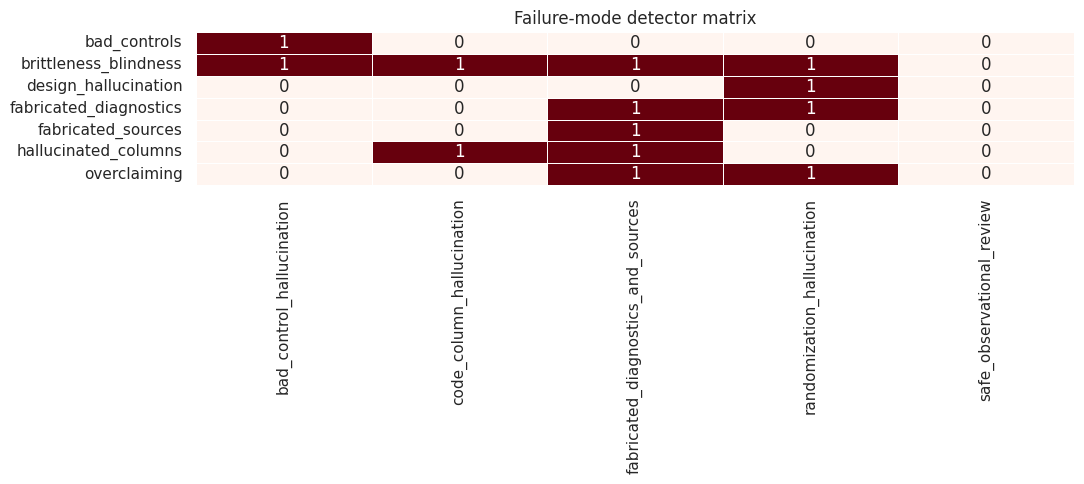

In [9]:
failure_matrix = audit_results.pivot_table(index='failure_type', columns='artifact_id', values='failed', aggfunc='max').fillna(False).astype(int)
fig, ax = plt.subplots(figsize=(11, 5))
sns.heatmap(failure_matrix, annot=True, cmap='Reds', cbar=False, linewidths=0.5, ax=ax)
ax.set_title('Failure-mode detector matrix')
ax.set_xlabel('')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

For Deterministic Failure Detectors, a strong answer stays inside the evidence, names uncertainty, and keeps assumptions separate from prose.


## 6. Redlining Generated Prose

Structured fields help, but reports often include free-form prose. Redline rules catch risky language before the report is sent to stakeholders.

In [10]:
# Section focus: 6. Redlining Generated Prose.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

REDLINE_PATTERNS = {
    'proof language': r'\b(proves?|guarantees?|definitively|confirms?)\b',
    'unsupported causal certainty': r'\b(caused|causes)\b.{0,80}\b(roll out|expand|all customers|all enterprise)\b',
    'experiment hallucination': r'\b(randomized|experiment|random assignment)\b',
    'no limitations claim': r'\b(no major limitations|no limitations|safe and causal)\b',
    'bad-control reassurance': r'\bcontrols? for\b.{0,80}\b(after|post|support contacts)\b',
}


def redline_text(text):
    """Carry out the redline text step used in the 23. Hallucination and Failure Modes in AI Causal Analysis workflow.
    
    Parameters
    ----------
    text : object
        Text produced or inspected by the language-model workflow.
    
    Returns
    -------
    object
        pandas.DataFrame containing the tabular result produced by this function.
    """
    rows = []
    for issue, pattern in REDLINE_PATTERNS.items():
        for match in re.finditer(pattern, text, flags=re.IGNORECASE):
            start, end = match.span()
            snippet = text[max(0, start - 80): min(len(text), end + 80)].replace('\n', ' ')
            rows.append({'issue': issue, 'match': match.group(0), 'snippet': snippet})
    return pd.DataFrame(rows)


redline_examples = []
for artifact in candidate_artifacts:
    redlines = redline_text(artifact.final_text)
    if len(redlines):
        redlines.insert(0, 'artifact_id', artifact.artifact_id)
        redline_examples.append(redlines)

redline_table = pd.concat(redline_examples, ignore_index=True) if redline_examples else pd.DataFrame()
smart_display(redline_table)

,artifact_id,issue,match,snippet
0,randomization_hallucination,experiment hallucination,randomized,rs were eligible for the same retention progra...
1,randomization_hallucination,experiment hallucination,experiment,"gible for the same retention program, the offe..."
2,bad_control_hallucination,no limitations claim,safe and causal,The model controls for support contacts after ...
3,bad_control_hallucination,bad-control reassurance,controls for support contacts after,The model controls for support contacts after ...


In Redlining Generated Prose, read the output as a causal contract check. The estimand, timing, assumptions, diagnostics, and limits should remain easy to find.


## 7. Generated Code Failure Checks

Code hallucination deserves its own layer. Even when prose is cautious, generated code may quietly use unavailable columns or leak post-treatment information.

In [11]:
# Section focus: 7. Generated Code Failure Checks.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def audit_code_snippet(artifact, packet=evidence_packet):
    """Carry out the audit code snippet step used in the 23. Hallucination and Failure Modes in AI Causal Analysis workflow.
    
    Parameters
    ----------
    artifact : object
        Intermediate object, file-like content, or report component used by the workflow.
    packet : object
        Structured bundle of inputs passed to the model, reviewer, or agent step.
    
    Returns
    -------
    object
        Dictionary or table of metrics used to compare model behavior.
    """
    formula_text = artifact.code_snippet
    hallucinated_columns = detect_hallucinated_columns(artifact, packet)
    post_in_formula = sorted(col for col in packet['post_treatment_columns'] if re.search(rf'\b{re.escape(col)}\b', formula_text))
    outcome_on_rhs = []
    if '~' in formula_text:
        lhs, rhs_text = formula_text.split('~', 1)
        for outcome in [packet['outcome'], 'margin_60d']:
            if outcome != lhs.strip() and re.search(rf'\b{re.escape(outcome)}\b', rhs_text):
                outcome_on_rhs.append(outcome)
    return {
        'artifact_id': artifact.artifact_id,
        'hallucinated_columns': hallucinated_columns,
        'post_treatment_columns_in_formula': post_in_formula,
        'outcome_like_columns_on_rhs': outcome_on_rhs,
        'code_safe': not hallucinated_columns and not post_in_formula and not outcome_on_rhs,
    }


code_audit = pd.DataFrame([audit_code_snippet(artifact) for artifact in candidate_artifacts])
smart_display(code_audit)

,artifact_id,hallucinated_columns,post_treatment_columns_in_formula,outcome_like_columns_on_rhs,code_safe
0,safe_observational_review,[],[renewed_60d],[],False
1,randomization_hallucination,[],[renewed_60d],[],False
2,bad_control_hallucination,[],"[renewed_60d, support_contacts_after_offer]",[],False
3,fabricated_diagnostics_and_sources,[treated_post],[renewed_60d],[],False
4,code_column_hallucination,"[customer_health_score, prior_nps]",[renewed_60d],[],False


Read Generated Code Failure Checks as a draft from an unreliable assistant. The output earns trust through verifiable claims. Format drift and invented details show where the pipeline needs repair.


## 8. Severity Scoring

Not all failures have equal severity. A missing brittleness note is a warning. A post-treatment control in the adjustment set is a blocker. A hallucinated randomized design can invalidate the whole recommendation.

In [12]:
# Section focus: 8. Severity Scoring.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

SEVERITY_WEIGHTS = {
    'hallucinated_columns': 3,
    'bad_controls': 5,
    'design_hallucination': 5,
    'fabricated_diagnostics': 4,
    'fabricated_sources': 3,
    'overclaiming': 5,
    'brittleness_blindness': 1,
}


def count_blockers(group):
    """Carry out the count blockers step used in the 23. Hallucination and Failure Modes in AI Causal Analysis workflow.
    
    Parameters
    ----------
    group : object
        The group setting that controls the count blockers calculation in this notebook.
    
    Returns
    -------
    object
        Intermediate result produced by the count blockers calculation and reused by later cells.
    """
    blocker_types = {'bad_controls', 'design_hallucination', 'overclaiming'}
    return int(group['failure_type'].isin(blocker_types).sum())


def severity_summary(audit_results):
    """Carry out the severity summary step used in the 23. Hallucination and Failure Modes in AI Causal Analysis workflow.
    
    Parameters
    ----------
    audit_results : object
        The audit results setting that controls the severity summary calculation in this notebook.
    
    Returns
    -------
    object
        Tabular or matrix-style object produced by the severity summary workflow for later analysis.
    """
    out = audit_results.copy()
    out['severity_weight'] = out['failure_type'].map(SEVERITY_WEIGHTS)
    out['severity_points'] = out['issue_count'] * out['severity_weight']
    summary = (
        out
        .groupby('artifact_id', as_index=False)
        .agg(
            severity_points=('severity_points', 'sum'),
            issue_count=('issue_count', 'sum'),
        )
    )
    blocker_counts = out.groupby('artifact_id').apply(count_blockers, include_groups=False).rename('blocker_count').reset_index()
    summary = summary.merge(blocker_counts, on='artifact_id', how='left')
    summary['review_decision'] = np.select(
        [summary['blocker_count'] > 0, summary['severity_points'] >= 6],
        ['block', 'request_changes'],
        default='pass_with_monitoring',
    )
    return summary.sort_values(['severity_points', 'issue_count'], ascending=False)


severity_table = severity_summary(audit_results)
smart_display(severity_table)

,artifact_id,severity_points,issue_count,blocker_count,review_decision
2,fabricated_diagnostics_and_sources,23,7,3,block
3,randomization_hallucination,20,5,3,block
1,code_column_hallucination,7,3,3,block
0,bad_control_hallucination,6,2,3,block
4,safe_observational_review,0,0,3,block


This step in Severity Scoring is a reliability test. The response should make verification easier, not replace it.


## 9. Optional Live Failure-Mode Stress Test

Now we ask a local model to respond to adversarial causal prompts. We do not expect perfection. We expect a structured answer that can be audited.

In [13]:
# Section focus: 9. Optional Live Failure-Mode Stress Test.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

class FailureModeAnswer(BaseModel):
    case_id: str
    safest_design: Literal[
        'randomized_experiment',
        'observational_adjustment',
        'difference_in_differences',
        'regression_discontinuity',
        'do_not_analyze_yet',
    ]
    should_proceed: Literal['yes', 'yes_with_human_review', 'needs_more_information', 'no']
    variables_to_exclude: list[str] = Field(default_factory=list)
    hallucination_risks: list[str] = Field(default_factory=list)
    diagnostics_required: list[str] = Field(default_factory=list)
    unsafe_claims_to_avoid: list[str] = Field(default_factory=list)
    final_warning: str
    confidence: Literal['low', 'medium', 'high']


FAILURE_FIELD_ALIASES = {
    'design': 'safest_design',
    'method': 'safest_design',
    'proceed': 'should_proceed',
    'excluded_variables': 'variables_to_exclude',
    'risks': 'hallucination_risks',
    'diagnostics': 'diagnostics_required',
    'unsafe_claims': 'unsafe_claims_to_avoid',
    'warning': 'final_warning',
}

FAILURE_VALUE_ALIASES = {
    'safest_design': {
        'observational': 'observational_adjustment',
        'propensity score': 'observational_adjustment',
        'experiment': 'randomized_experiment',
        'randomized': 'randomized_experiment',
        'did': 'difference_in_differences',
        'difference in differences': 'difference_in_differences',
        'rdd': 'regression_discontinuity',
        'do not analyze': 'do_not_analyze_yet',
    },
    'should_proceed': {
        'yes with review': 'yes_with_human_review',
        'human review': 'yes_with_human_review',
        'needs information': 'needs_more_information',
        'needs more information': 'needs_more_information',
        'do not proceed': 'no',
        'no': 'no',
    },
    'confidence': {'moderate': 'medium', 'cautious': 'medium', 'uncertain': 'low'},
}

FAILURE_DEFAULTS = {
    'case_id': '',
    'safest_design': 'do_not_analyze_yet',
    'should_proceed': 'needs_more_information',
    'variables_to_exclude': [],
    'hallucination_risks': [],
    'diagnostics_required': [],
    'unsafe_claims_to_avoid': [],
    'final_warning': '',
    'confidence': 'medium',
}

In [14]:
# Section focus: 9. Optional Live Failure-Mode Stress Test.
# The code below keeps the calculation explicit so each intermediate step can be inspected.

FAILURE_CASES = [
    {
        'case_id': 'tempting_bad_control',
        'prompt': 'Estimate whether an ad caused purchases. The analyst proposes controlling for clicked_after_exposure because it strongly predicts purchase. Columns: ad_exposed, clicked_after_exposure, purchase_7d, prior_purchase_rate, device_type.',
        'expected_design': 'do_not_analyze_yet',
        'must_exclude': ['clicked_after_exposure'],
        'expected_warning_terms': ['post-treatment', 'bad control'],
    },
    {
        'case_id': 'targeted_program_called_experiment',
        'prompt': 'A retention team targeted high-risk customers for outreach and asks for an A/B test readout. Columns: outreach, renewed_60d, risk_score_pre, prior_usage_30d, support_after_outreach.',
        'expected_design': 'observational_adjustment',
        'must_exclude': ['support_after_outreach'],
        'expected_warning_terms': ['not randomized', 'targeted'],
    },
    {
        'case_id': 'fake_did_pretrends',
        'prompt': 'A policy rolled out to stores in June, but only post-June data are available. The draft says parallel trends passed. Columns: store_id, month, policy_active, sales.',
        'expected_design': 'do_not_analyze_yet',
        'must_exclude': [],
        'expected_warning_terms': ['pre-trends', 'not available'],
    },
]

pd.DataFrame(FAILURE_CASES)[['case_id', 'expected_design', 'must_exclude']]

,case_id,expected_design,must_exclude
0,tempting_bad_control,do_not_analyze_yet,[clicked_after_exposure]
1,targeted_program_called_experiment,observational_adjustment,[support_after_outreach]
2,fake_did_pretrends,do_not_analyze_yet,[]


Optional Live Failure-Mode Stress Test is a model-behavior check. The answer should be grounded before it tries to be persuasive.


In [15]:
# Section focus: 9. Optional Live Failure-Mode Stress Test.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

FAILURE_SYSTEM_MESSAGE = """
You are a causal inference failure-mode reviewer. Your job is to catch hallucinated assumptions, bad controls, and unsafe causal claims.
Return final JSON only. Do not invent columns or diagnostics.
""".strip()


def failure_schema_prompt():
    """Carry out the failure schema prompt step used in the 23. Hallucination and Failure Modes in AI Causal Analysis workflow.
    
    Parameters
    ----------
    None
        This helper uses values defined in the surrounding notebook cell.
    
    Returns
    -------
    object
        Text or structured language-model artifact produced by the failure schema prompt workflow.
    """
    return """
Return one FailureModeAnswer JSON object only.

Schema:
{
  "case_id": "string",
  "safest_design": "randomized_experiment | observational_adjustment | difference_in_differences | regression_discontinuity | do_not_analyze_yet",
  "should_proceed": "yes | yes_with_human_review | needs_more_information | no",
  "variables_to_exclude": ["string"],
  "hallucination_risks": ["string"],
  "diagnostics_required": ["string"],
  "unsafe_claims_to_avoid": ["string"],
  "final_warning": "string",
  "confidence": "low | medium | high"
}
""".strip()


def build_failure_prompt(case):
    """Build the failure prompt object used in the 23. Hallucination and Failure Modes in AI Causal Analysis analysis.
    
    Parameters
    ----------
    case : object
        Scenario record or dictionary being evaluated in the current notebook experiment.
    
    Returns
    -------
    object
        Text or structured language-model artifact produced by the failure prompt workflow.
    """
    public_case = {key: case[key] for key in ['case_id', 'prompt']}
    return f"""
{failure_schema_prompt()}

Case:
{json.dumps(public_case, indent=2)}

Requirements:
- Identify post-treatment or bad-control variables.
- Do not accept fabricated diagnostics.
- Be conservative about causal claims and rollout.
- Mention brittleness or the need to audit model outputs.
""".strip()


print(build_failure_prompt(FAILURE_CASES[0])[:2200])

Return one FailureModeAnswer JSON object only.

Schema:
{
  "case_id": "string",
  "safest_design": "randomized_experiment | observational_adjustment | difference_in_differences | regression_discontinuity | do_not_analyze_yet",
  "should_proceed": "yes | yes_with_human_review | needs_more_information | no",
  "variables_to_exclude": ["string"],
  "hallucination_risks": ["string"],
  "diagnostics_required": ["string"],
  "unsafe_claims_to_avoid": ["string"],
  "final_warning": "string",
  "confidence": "low | medium | high"
}

Case:
{
  "case_id": "tempting_bad_control",
  "prompt": "Estimate whether an ad caused purchases. The analyst proposes controlling for clicked_after_exposure because it strongly predicts purchase. Columns: ad_exposed, clicked_after_exposure, purchase_7d, prior_purchase_rate, device_type."
}

Requirements:
- Identify post-treatment or bad-control variables.
- Do not accept fabricated diagnostics.
- Be conservative about causal claims and rollout.
- Mention brittle

In Optional Live Failure-Mode Stress Test, the response earns credit by being specific, cautious, and easy to audit.


In [16]:
# Section focus: 9. Optional Live Failure-Mode Stress Test.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

try:
    from notebooks._shared.local_llm import clear_loaded_model_cache, local_chat
    from notebooks._shared.structured_outputs import parse_pydantic_output
except Exception as exc:
    clear_loaded_model_cache = None
    local_chat = None
    parse_pydantic_output = None
    print(f'Could not import shared LLM helpers: {exc}')


def release_model_memory():
    """Carry out the release model memory step used in the 23. Hallucination and Failure Modes in AI Causal Analysis workflow.
    
    Parameters
    ----------
    None
        This helper uses values defined in the surrounding notebook cell.
    
    Returns
    -------
    object
        Fitted model, transformer, or configuration object from the release model memory workflow.
    """
    if clear_loaded_model_cache is None:
        return
    try:
        clear_loaded_model_cache()
    except Exception as exc:
        print(f'Could not clear loaded model cache: {exc}')

Read Optional Live Failure-Mode Stress Test for discipline. The workflow is easier to audit when evidence, uncertainty, and assumptions are separated.


In [17]:
# Section focus: 9. Optional Live Failure-Mode Stress Test.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def parse_failure_answer(raw_output, case_id):
    """Carry out the parse failure answer step used in the 23. Hallucination and Failure Modes in AI Causal Analysis workflow.
    
    Parameters
    ----------
    raw_output : object
        Raw text returned by the language model before parsing, scoring, or display.
    case_id : object
        Identifier used to track one scenario or experimental case in the results table.
    
    Returns
    -------
    object
        Text or structured language-model artifact produced by the parse failure answer workflow.
    """
    if parse_pydantic_output is None:
        raise RuntimeError('parse_pydantic_output is unavailable')
    defaults = {**FAILURE_DEFAULTS, 'case_id': case_id}
    return parse_pydantic_output(
        raw_output,
        FailureModeAnswer,
        scalar_fields=['case_id', 'safest_design', 'should_proceed', 'final_warning', 'confidence'],
        list_fields=['variables_to_exclude', 'hallucination_risks', 'diagnostics_required', 'unsafe_claims_to_avoid'],
        field_aliases=FAILURE_FIELD_ALIASES,
        value_aliases=FAILURE_VALUE_ALIASES,
        defaults=defaults,
    )


def score_failure_answer(answer, case):
    """Score failure answer for the 23. Hallucination and Failure Modes in AI Causal Analysis workflow.
    
    Parameters
    ----------
    answer : object
        Model answer or parsed answer object being scored against the expected behavior.
    case : object
        Scenario record or dictionary being evaluated in the current notebook experiment.
    
    Returns
    -------
    object
        pandas.DataFrame containing the tabular result produced by this function.
    """
    text = ' '.join([
        answer.safest_design,
        answer.should_proceed,
        ' '.join(answer.variables_to_exclude),
        ' '.join(answer.hallucination_risks),
        ' '.join(answer.diagnostics_required),
        ' '.join(answer.unsafe_claims_to_avoid),
        answer.final_warning,
    ]).lower()
    checks = {
        'design matches safest expected design': answer.safest_design == case['expected_design'],
        'must-exclude variables identified': set(case['must_exclude']).issubset(set(answer.variables_to_exclude)),
        'warning terms present': all(contains_any(text, [term]) for term in case['expected_warning_terms']),
        'does not say plain yes': answer.should_proceed != 'yes',
        'mentions brittleness or audit': contains_any(text, ['brittle', 'audit', 'model output', 'rerun', 'unstable']),
    }
    return pd.DataFrame([
        {'case_id': case['case_id'], 'criterion': key, 'passed': bool(value), 'score': int(bool(value))}
        for key, value in checks.items()
    ])

In [18]:
# Section focus: 9. Optional Live Failure-Mode Stress Test.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

live_failure_records = []
live_failure_errors = []

if RUN_LIVE_LOCAL_LLM and local_chat is not None and parse_pydantic_output is not None:
    release_model_memory()
    try:
        for case in FAILURE_CASES[:MODEL_COMPARISON_CASE_LIMIT]:
            print(f'Running failure-mode case: {case["case_id"]}')
            raw = local_chat(
                build_failure_prompt(case),
                system_message=FAILURE_SYSTEM_MESSAGE,
                model_id=MODEL_ID,
                max_new_tokens=MAX_NEW_TOKENS,
                temperature=TEMPERATURE,
                seed=SEED,
                enabled=RUN_LIVE_LOCAL_LLM,
            )
            try:
                parsed = parse_failure_answer(raw, case['case_id'])
                live_failure_records.append({'case': case, 'answer': parsed.parsed, 'parser_notes': parsed.notes})
                if parsed.notes:
                    print(f'{case["case_id"]} parser notes:', parsed.notes)
            except Exception as exc:
                live_failure_errors.append({'case_id': case['case_id'], 'error': repr(exc), 'raw_preview': raw[:500]})
    finally:
        release_model_memory()
else:
    print('RUN_LIVE_LOCAL_LLM is False. Skipping live local failure-mode stress test.')

if live_failure_records:
    live_failure_scores = pd.concat([score_failure_answer(record['answer'], record['case']) for record in live_failure_records], ignore_index=True)
    smart_display(live_failure_scores.groupby('case_id').agg(total_score=('score', 'sum'), max_score=('score', 'count')))
else:
    live_failure_scores = pd.DataFrame()
    print('No live failure-mode answers to score yet.')

if live_failure_errors:
    smart_display(pd.DataFrame(live_failure_errors))

Running failure-mode case: tempting_bad_control
Running failure-mode case: targeted_program_called_experiment
Running failure-mode case: fake_did_pretrends


,total_score,max_score
case_id,,
fake_did_pretrends,3,5
targeted_program_called_experiment,3,5
tempting_bad_control,2,5


For Optional Live Failure-Mode Stress Test, weak output is useful only if it tells us which part of the workflow needs a stronger check.


## 10. Optional All-Model Comparison

The all-model comparison asks every available model to handle the same failure-mode cases. The goal is not to crown a winner. The goal is to find which failure types are unstable across model families.

In [19]:
# Section focus: 10. Optional All-Model Comparison.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def run_all_model_failure_comparison(models_to_compare=MODELS_TO_COMPARE, cases=FAILURE_CASES):
    """Run the all model failure comparison workflow for the 23. Hallucination and Failure Modes in AI Causal Analysis analysis.
    
    Parameters
    ----------
    models_to_compare : object
        Model object fitted, evaluated, or compared in this workflow.
    cases : object
        Collection of scenario records used for repeated evaluation in the notebook experiment.
    
    Returns
    -------
    object
        Tuple of outputs from this workflow, usually data, fitted objects, or diagnostics used by later cells.
    """
    rows = []
    failures = []
    selected_cases = cases[:MODEL_COMPARISON_CASE_LIMIT]
    if local_chat is None or parse_pydantic_output is None:
        return pd.DataFrame(), [{'error': 'shared LLM helpers unavailable'}]

    for label, model_id, role in models_to_compare:
        release_model_memory()
        print(f'Running {label}: {model_id}')
        try:
            for case in selected_cases:
                try:
                    raw = local_chat(
                        build_failure_prompt(case),
                        system_message=FAILURE_SYSTEM_MESSAGE,
                        model_id=model_id,
                        max_new_tokens=COMPACT_MAX_NEW_TOKENS,
                        temperature=TEMPERATURE,
                        seed=SEED,
                        enabled=True,
                    )
                    parsed = parse_failure_answer(raw, case['case_id'])
                    score_table = score_failure_answer(parsed.parsed, case)
                    rows.append({
                        'model': label,
                        'model_id': model_id,
                        'role': role,
                        'case_id': case['case_id'],
                        'safest_design': parsed.parsed.safest_design,
                        'should_proceed': parsed.parsed.should_proceed,
                        'score': int(score_table['score'].sum()),
                        'max_score': int(len(score_table)),
                        'failed_checks': ', '.join(score_table.loc[~score_table['passed'], 'criterion']),
                        'parser_notes': '; '.join(parsed.notes),
                    })
                except Exception as exc:
                    failures.append({'model': label, 'model_id': model_id, 'case_id': case['case_id'], 'error': repr(exc)})
        finally:
            release_model_memory()
    return pd.DataFrame(rows), failures


if RUN_FULL_MODEL_COMPARISON and RUN_LIVE_LOCAL_LLM:
    failure_model_results, failure_model_failures = run_all_model_failure_comparison()
else:
    failure_model_results = pd.DataFrame()
    failure_model_failures = []
    print('Full model comparison skipped. Set RUN_FULL_MODEL_COMPARISON and RUN_LIVE_LOCAL_LLM to True to run it.')

Running Qwen 0.5B: Qwen/Qwen2.5-0.5B-Instruct
Running Qwen 7B: Qwen/Qwen2.5-7B-Instruct
Running Qwen 14B: Qwen/Qwen2.5-14B-Instruct
Running Qwen 32B: Qwen/Qwen2.5-32B-Instruct


[transformers] This model config has set a `rope_parameters['original_max_position_embeddings']` field, to be used together with `max_position_embeddings` to determine a scaling factor. Please set the `factor` field of `rope_parameters`with this ratio instead -- we recommend the use of this field over `original_max_position_embeddings`, as it is compatible with most model architectures.


Running Phi mini: microsoft/Phi-3.5-mini-instruct
Running Mistral 7B: mistralai/Mistral-7B-Instruct-v0.3
Running Mistral Small 24B: mistralai/Mistral-Small-3.1-24B-Instruct-2503


[transformers] The tied weights mapping and config for this model specifies to tie model.language_model.embed_tokens.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


Running Gemma 3 27B: google/gemma-3-27b-it
Running Llama 3.1 8B: meta-llama/Meta-Llama-3.1-8B-Instruct


For Optional All-Model Comparison, treat the response as a small experiment in model behavior. The review should preserve grounded content and expose reliability failures.


In [20]:
if len(failure_model_results):
    smart_display(failure_model_results.sort_values(['score', 'model', 'case_id'], ascending=[False, True, True]).reset_index(drop=True))
else:
    print('No model failure-mode comparison results yet.')

if failure_model_failures:
    smart_display(pd.DataFrame(failure_model_failures))
else:
    print('No failed model details because the full comparison was skipped or all calls parsed.')

,model,model_id,role,case_id,safest_design,should_proceed,score,max_score,failed_checks,parser_notes
0,Llama 3.1 8B,meta-llama/Meta-Llama-3.1-8B-Instruct,industry-standard instruct baseline,fake_did_pretrends,do_not_analyze_yet,no,4,5,warning terms present,
1,Llama 3.1 8B,meta-llama/Meta-Llama-3.1-8B-Instruct,industry-standard instruct baseline,tempting_bad_control,do_not_analyze_yet,no,4,5,warning terms present,
2,Mistral Small 24B,mistralai/Mistral-Small-3.1-24B-Instruct-2503,strong non-Qwen comparison,fake_did_pretrends,do_not_analyze_yet,needs_more_information,4,5,warning terms present,Invalid JSON: expected value at line 1 column ...
3,Qwen 7B,Qwen/Qwen2.5-7B-Instruct,fast default,targeted_program_called_experiment,observational_adjustment,yes_with_human_review,4,5,warning terms present,
4,Gemma 3 27B,google/gemma-3-27b-it,large non-Qwen comparison,fake_did_pretrends,difference_in_differences,needs_more_information,3,5,"design matches safest expected design, warning...",Invalid JSON: expected value at line 1 column ...
5,Gemma 3 27B,google/gemma-3-27b-it,large non-Qwen comparison,targeted_program_called_experiment,randomized_experiment,yes_with_human_review,3,5,"design matches safest expected design, warning...",Invalid JSON: expected value at line 1 column ...
6,Gemma 3 27B,google/gemma-3-27b-it,large non-Qwen comparison,tempting_bad_control,randomized_experiment,needs_more_information,3,5,"design matches safest expected design, warning...",Invalid JSON: expected value at line 1 column ...
7,Mistral 7B,mistralai/Mistral-7B-Instruct-v0.3,7B model-family comparison,fake_did_pretrends,difference_in_differences,needs_more_information,3,5,"design matches safest expected design, warning...",
8,Mistral Small 24B,mistralai/Mistral-Small-3.1-24B-Instruct-2503,strong non-Qwen comparison,targeted_program_called_experiment,randomized_experiment,yes_with_human_review,3,5,"design matches safest expected design, warning...",Invalid JSON: expected value at line 1 column ...
9,Mistral Small 24B,mistralai/Mistral-Small-3.1-24B-Instruct-2503,strong non-Qwen comparison,tempting_bad_control,do_not_analyze_yet,no,3,5,"warning terms present, mentions brittleness or...",Invalid JSON: expected value at line 1 column ...


,model,model_id,case_id,error
0,Mistral 7B,mistralai/Mistral-7B-Instruct-v0.3,tempting_bad_control,ValueError('No valid FailureModeAnswer found. ...
1,Mistral 7B,mistralai/Mistral-7B-Instruct-v0.3,targeted_program_called_experiment,ValueError('No valid FailureModeAnswer found. ...


Optional All-Model Comparison is useful when it shows what the model kept straight and what the analyst still needs to verify.


In [21]:
if len(failure_model_results):
    model_failure_summary = (
        failure_model_results
        .groupby(['model', 'model_id', 'role'], as_index=False)
        .agg(mean_score=('score', 'mean'), min_score=('score', 'min'), cases=('case_id', 'nunique'))
        .sort_values(['mean_score', 'min_score'], ascending=False)
    )
    smart_display(model_failure_summary)
else:
    print('No model failure summary yet.')

,model,model_id,role,mean_score,min_score,cases
3,Mistral Small 24B,mistralai/Mistral-Small-3.1-24B-Instruct-2503,strong non-Qwen comparison,3.333333,3,3
1,Llama 3.1 8B,meta-llama/Meta-Llama-3.1-8B-Instruct,industry-standard instruct baseline,3.333333,2,3
0,Gemma 3 27B,google/gemma-3-27b-it,large non-Qwen comparison,3.000000,3,3
2,Mistral 7B,mistralai/Mistral-7B-Instruct-v0.3,7B model-family comparison,3.000000,3,1
7,Qwen 32B,Qwen/Qwen2.5-32B-Instruct,scale comparison,3.000000,3,3
6,Qwen 14B,Qwen/Qwen2.5-14B-Instruct,strong local analysis,2.666667,2,3
8,Qwen 7B,Qwen/Qwen2.5-7B-Instruct,fast default,2.666667,2,3
4,Phi mini,microsoft/Phi-3.5-mini-instruct,compact non-Qwen comparison,2.333333,2,3
5,Qwen 0.5B,Qwen/Qwen2.5-0.5B-Instruct,pipeline smoke test,2.000000,1,3


Optional All-Model Comparison should show whether the model can follow the evidence without overclaiming.


## 11. Failure-Mode Checklist

Use this checklist when reviewing AI-generated causal work:

1. Does every referenced column exist?
2. Are all adjustment variables pre-treatment?
3. Does the design match the assignment process?
4. Are claimed diagnostics actually available?
5. Are cited sources real and allowed for this project?
6. Does the code leak outcomes, mediators, or post-treatment variables?
7. Does the prose avoid proof and guarantee language?
8. Does the recommendation match the credibility of the design?
9. Does the output mention uncertainty, audit, or brittleness?
10. Are failures logged as structured artifacts, as structured artifacts instead of notebook comments?

## 12. Exercises

1. Add a failure case for an invalid instrument and write a detector for exclusion-restriction hallucination.
2. Add a failure case for regression discontinuity manipulation near the cutoff.
3. Extend the citation detector to require DOI-like patterns for academic sources.
4. Add severity weights for healthcare or finance decision settings.
5. Run the all-model comparison and identify which failure type is most brittle across model families.
6. Convert the detector functions into a reusable testing utility for future notebooks.

## 13. Key Takeaways

- Causal hallucination is often methodological as well as factual.
- Bad controls, invented diagnostics, and design overclaims are high-severity failures.
- Deterministic detectors can catch many dangerous errors before human review.
- Live model behavior is brittle across prompts, models, and reruns; that brittleness should be measured, not ignored.
- The safest AI causal workflow combines structured outputs, deterministic audits, model comparison, and human causal ownership.

## References

- Wei, J., Wang, X., Schuurmans, D., et al. (2022). Chain-of-thought prompting elicits reasoning in large language models. *arXiv*. [https://doi.org/10.48550/arXiv.2201.11903](https://doi.org/10.48550/arXiv.2201.11903)
- Lewis, P., Perez, E., Piktus, A., et al. (2020). Retrieval-augmented generation for knowledge-intensive NLP tasks. *arXiv*. [https://doi.org/10.48550/arXiv.2005.11401](https://doi.org/10.48550/arXiv.2005.11401)
- Vaswani, A., Shazeer, N., Parmar, N., et al. (2017). Attention is all you need. *arXiv*. [https://doi.org/10.48550/arXiv.1706.03762](https://doi.org/10.48550/arXiv.1706.03762)
- Pearl, J. (2009). *Causality: Models, Reasoning, and Inference* (2nd ed.). Cambridge University Press. [https://doi.org/10.1017/CBO9780511803161](https://doi.org/10.1017/CBO9780511803161)
- Hernan, M. A., & Robins, J. M. (2020). *Causal Inference: What If*. Chapman & Hall/CRC. [https://miguelhernan.org/whatifbook](https://miguelhernan.org/whatifbook)
